# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [1]:
import pandas as pd

#url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
#df = pd.read_csv(url)

df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [2]:
df.shape

(17379, 17)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


Initially I will remove these columns data ('instant','dteday') as they do not give interesting information.

After some trial and error, I need to remove more columns ('casual','registered') as they were already summing up the cnt value.

In [4]:
#df = df.drop(['instant','dteday'], axis=1)
df = df.drop(['instant','dteday','casual','registered'], axis=1)
df.head(10)

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,1
5,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,1
6,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2
7,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,3
8,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,8
9,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,14


Searching on the web and with AI help, it was found that for optimizing the linear regression is a good practice to do a One-hot encoding.  My first Linear Regression iteration gime me a R-squared=0.38.

Then the one-hot encoding will be done in the following code:

In [5]:
# Apply One-Hot Encoding with drop_first=True
df_encoded = pd.get_dummies(
    df,
    columns=['hr', 'season', 'weathersit', 'mnth', 'weekday'],
    drop_first=True,
    dtype=float
)

# Changes the data base
X = df_encoded

# Verification of new dimensions
print(f"Dimensions before: {df.shape}")
print(f"Dimensions after: {df_encoded.shape}")

X.head(10)

Dimensions before: (17379, 13)
Dimensions after: (17379, 54)


,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,hr_1,hr_2,...,mnth_9,mnth_10,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,0,0,0,0.24,0.2879,0.81,0.0000,16,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0,0,0.22,0.2727,0.80,0.0000,40,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0,0,0.22,0.2727,0.80,0.0000,32,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0,0,0.24,0.2879,0.75,0.0000,13,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0,0,0.24,0.2879,0.75,0.0000,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0,0,0,0.24,0.2576,0.75,0.0896,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,0,0,0,0.22,0.2727,0.80,0.0000,2,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7,0,0,0,0.20,0.2576,0.86,0.0000,3,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,0,0,0,0.24,0.2879,0.75,0.0000,8,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,0,0,0,0.32,0.3485,0.76,0.0000,14,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [6]:
from sklearn.model_selection import train_test_split
target = 'cnt'

# For Linear regresion model commented, uncomment for XGBR
# X = df.copy()

y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Add plotting to understand the data behaviour for 'cnt'

<Axes: xlabel='cnt', ylabel='Count'>

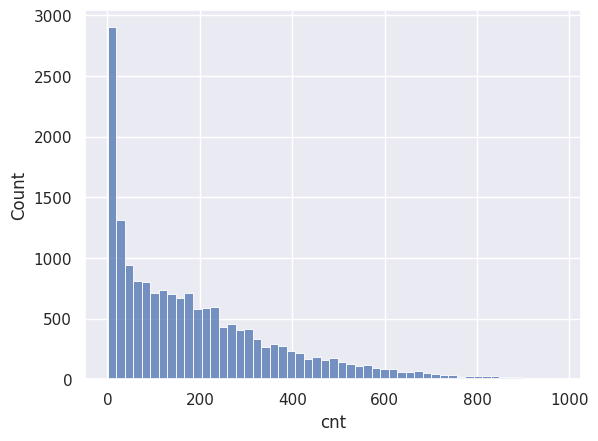

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

sns.histplot(x=df['cnt'])

I will use correlation data to see how is the match between variables.

In [8]:
corr_matrix = df.corr()
corr_matrix['cnt'].sort_values(ascending=False)

,cnt
cnt,1.000000
temp,0.404772
atemp,0.400929
hr,0.394071
yr,0.250495
season,0.178056
mnth,0.120638
windspeed,0.093234
workingday,0.030284
weekday,0.026900


Now, it will be plotted the data behaviour for each column data.

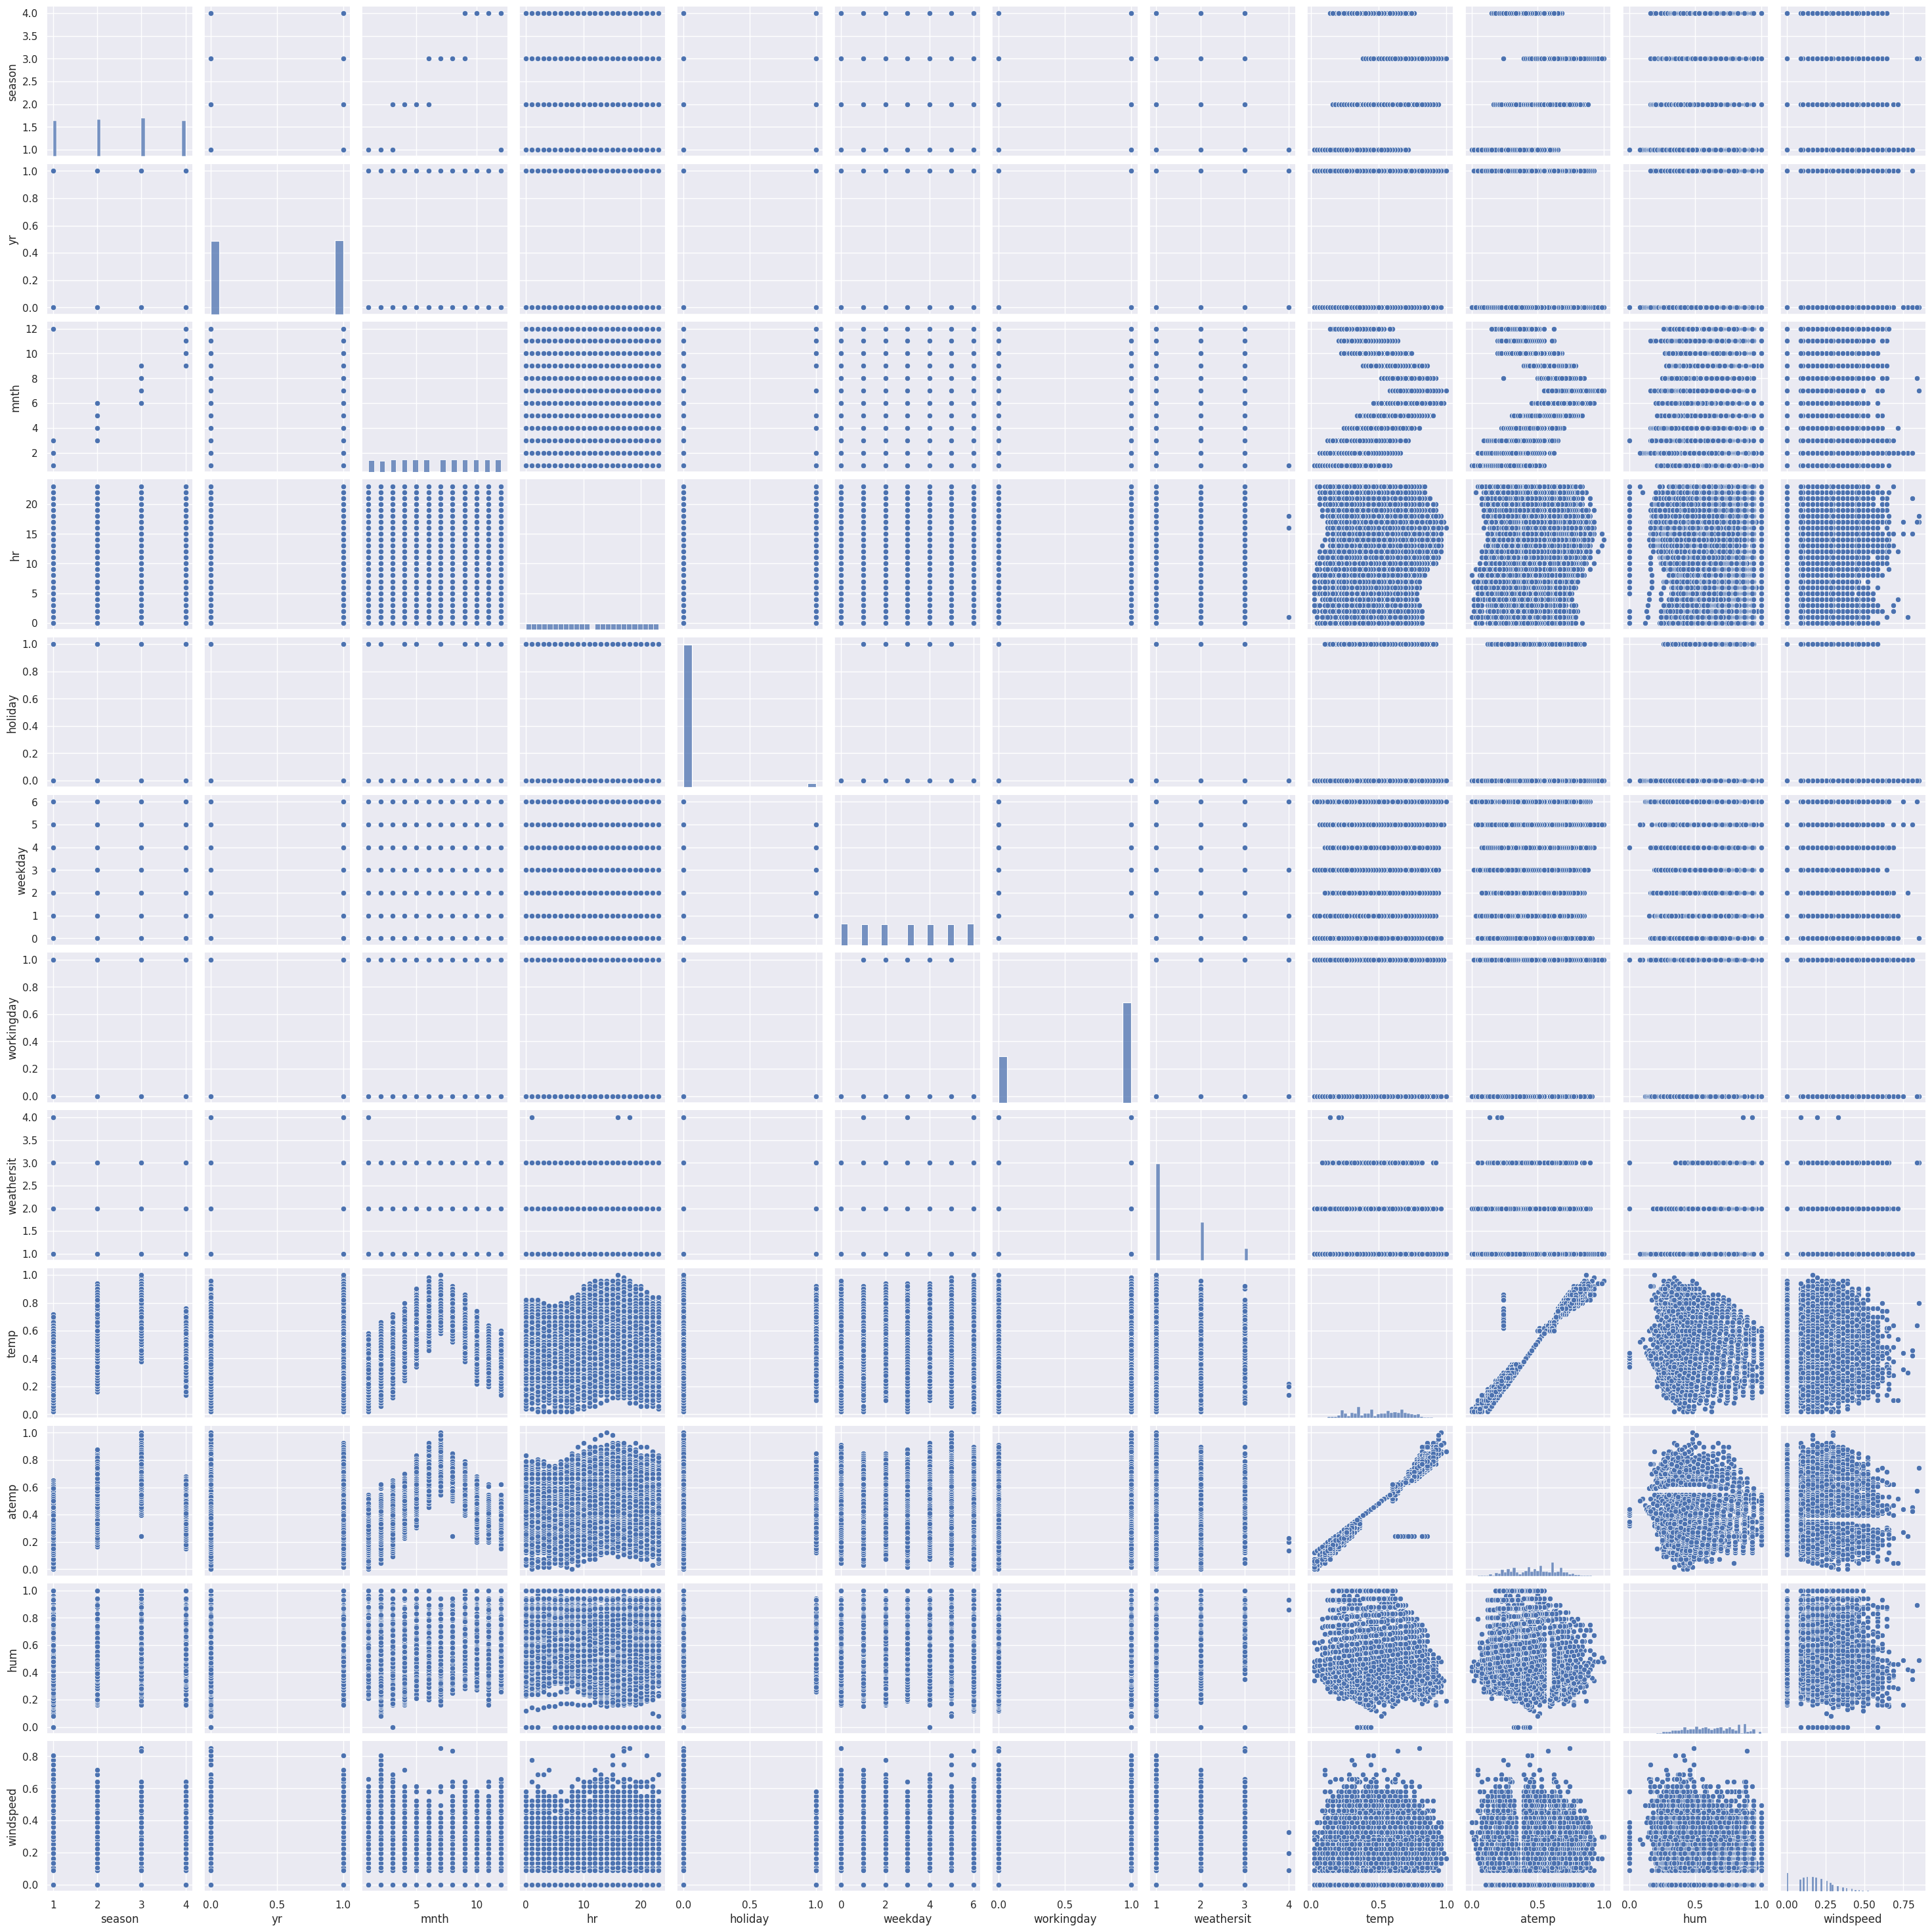

In [ ]:
x = df.drop(['cnt'], axis=1)
y = df['cnt']

sns.pairplot(x)

I also will need to normalize some values to try to get better results, as the first try was not good for the Linear Regression model.
I will try the StandardScaler and the MinMaxScaler to evaluate the differences between them.
At least for this case, I did not find any noticeable difference.



In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Normalize the features
scaler = StandardScaler()
#scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

LINEAR REGRESSION MODEL

No hyperparameter were modified. After searching for them online I found that is not needed for this model case.

HYPERPARAMETER FOR THE XGBRegressor MODEL

Particularly for the XGBRegressor model, some Hyperparameter were adjusted with a trial and error approach, after running a first trial with some initial values suggested in an AI consulting request.  Also, no normalized values were used fo this model, as according with the model characteristics it is not needed.


In [10]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Define a parameter grid for hyperparameter tuning
#param_grid = {
#    'n_estimators': [100, 200],
#    'max_depth': [4, 6, 8],
#    'learning_rate': [0.05, 0.1],
#    'subsample': [0.8, 1.0]
#}
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [8, 10, 12],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.6, 0.8]
}
# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.6}
Best Score: -2337.4251422417774


In [11]:
print("Best Score:", grid_search.best_estimator_)

Best Score: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


First run:


Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}

Best Score: -1544.3351323622362

## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

LINEAR REGRESSION MODEL

In [15]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model
model = LinearRegression()

# Fit the model to the training data
# model.fit(X_train, y_train)

# Predict the test data with the fitted model
# y_pred = model.predict(X_test)

# Adjusted for normalization
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

Evaluation of the model's performance using various metrics, such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2).

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 74.10515899029578
Mean Squared Error: 10089.38811515939
R-squared: 0.681375112801918


1st try:

Mean Absolute Error: 104.8033508955442
Mean Squared Error: 19379.828367651717
R-squared: 0.38798115831391344

## Visualize the predictions and compare the models
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

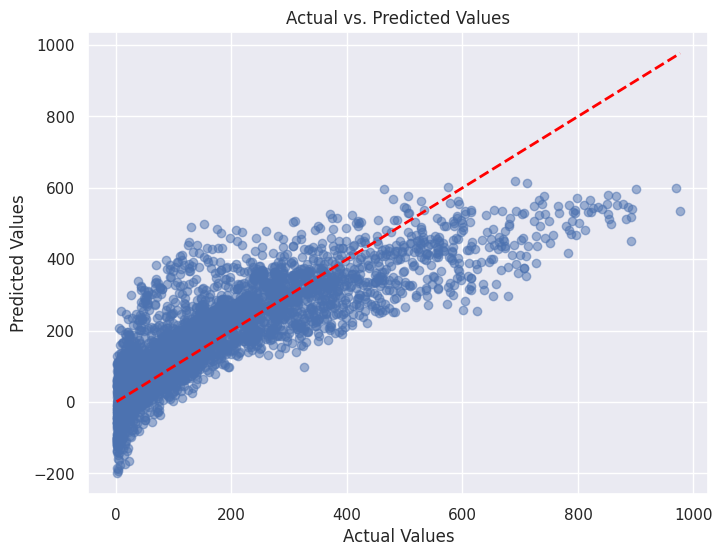

In [17]:
import matplotlib.pyplot as plt

# y_test contains the actual target values for the test dataset
# y_pred contains the predicted values for the test dataset

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

GRADIENT BOOSTING MODEL

Now with Gradient Boosting model, just to compare it with XGBoost for curiosity evaluation.

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

# Key hyperparameters: learning_rate and subsample
model = GradientBoostingRegressor(learning_rate=0.1, subsample=0.8)
model.fit(X_train, y_train)

# Predict the test data with the fitted model
y_pred = model.predict(X_test)

Evaluation of the model's performance using various metrics, such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2).

In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 56.90592085338155
Mean Squared Error: 6149.974431441121
R-squared: 0.8057825819442115


First run without optimization:

Mean Absolute Error: 45.49232867899605
Mean Squared Error: 4439.28789679028
R-squared: 0.8598064035985131

Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

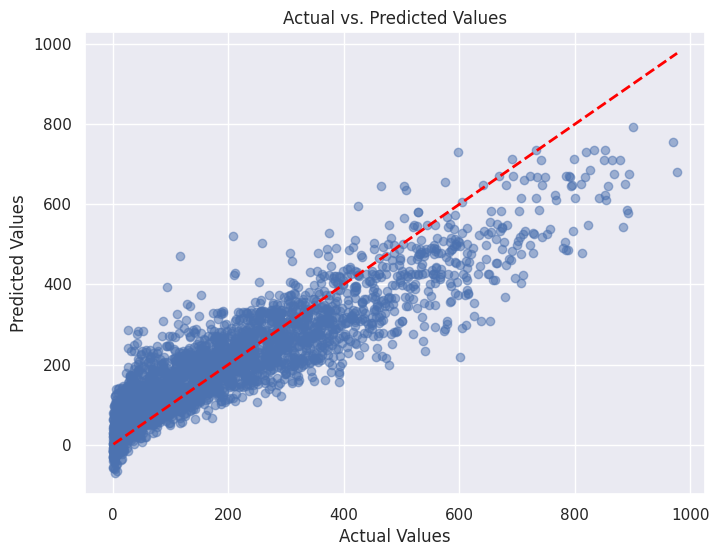

In [20]:
# y_test contains the actual target values for the test dataset
# y_pred contains the predicted values for the test dataset

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

NOW WITH XGBOOST MODEL

In [21]:
#from xgboost import XGBRegressor

# Key hyperparameters: learning_rate and subsample
# xgb_model = XGBRegressor(learning_rate=0.1, subsample=0.8, random_state=42)
# xgb_model.fit(X_train, y_train)

# Predict the test data with the fitted model
# y_pred = xgb_model.predict(X_test)

# Optimum model
best_xgb_model = grid_search.best_estimator_

# Predict over test data
y_pred = best_xgb_model.predict(X_test)

Evaluation of the model's performance using various metrics, such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2).

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 29.69611684053116
Mean Squared Error: 2192.8516085621627
R-squared: 0.9307493092301155


First run without optimization:

Mean Absolute Error: 25.277576486763337
Mean Squared Error: 1682.484219995195
R-squared: 0.9468668130624239

Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

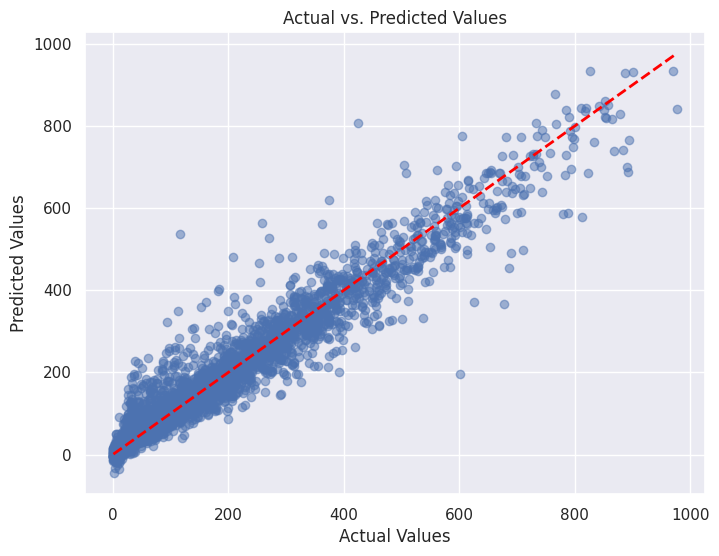

In [23]:
import matplotlib.pyplot as plt

# y_test contains the actual target values for the test dataset
# y_pred contains the predicted values for the test dataset

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()